# Turn control — results (sprint 098 + ring-tuning)

Charts of what changed, on the real robot over the radio / on the stand.

**The arc:** turns had a speed-dependent overshoot (a +8–10° "ridge" at 90° full
speed). Adding an **outer heading feedback loop** (Ruckig plans heading → PD
correction against measured heading → unchanged wheel PID) made turns terminate
on target. Then a **velocity-loop ring** in the trajectory was tamed on the stand.

All data is real hardware: `tests/bench/turn_sweep.py --relay --both` (endpoints)
and per-frame telemetry traces.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
OUT = Path("out")
TW = 128.0  # [mm] trackwidth

def load(*names):
    return pd.concat([pd.read_csv(OUT/n) for n in names], ignore_index=True)

# endpoint sweeps at the three eras
openloop = load("turn_sweep.csv", "turn_sweep2.csv", "turn_sweep_trace.csv")   # pre-heading-loop
final    = load("turn_sweep_ringtuned_final.csv")                             # shipped build
for d in (openloop, final):
    d["mag"] = d.cmd_deg.abs()
def stats(d):
    return dict(mean=d.overshoot_deg.abs().mean(), mx=d.overshoot_deg.abs().max(),
                within1=100*(d.overshoot_deg.abs()<=1).mean(), n=len(d))
print("open-loop :", {k:round(v,2) for k,v in stats(openloop).items()})
print("final     :", {k:round(v,2) for k,v in stats(final).items()})

open-loop : {'mean': np.float64(3.41), 'mx': np.float64(11.65), 'within1': np.float64(18.97), 'n': 58}
final     : {'mean': np.float64(0.4), 'mx': np.float64(1.75), 'within1': np.float64(95.0), 'n': 40}


## 1. The headline — turns land on target now

Overshoot by cell (angle × wheel-speed ceiling). **Left = before (open-loop):**
the bright band at 90°/high-speed is the "ridge". **Right = after:** flat and
near zero everywhere.

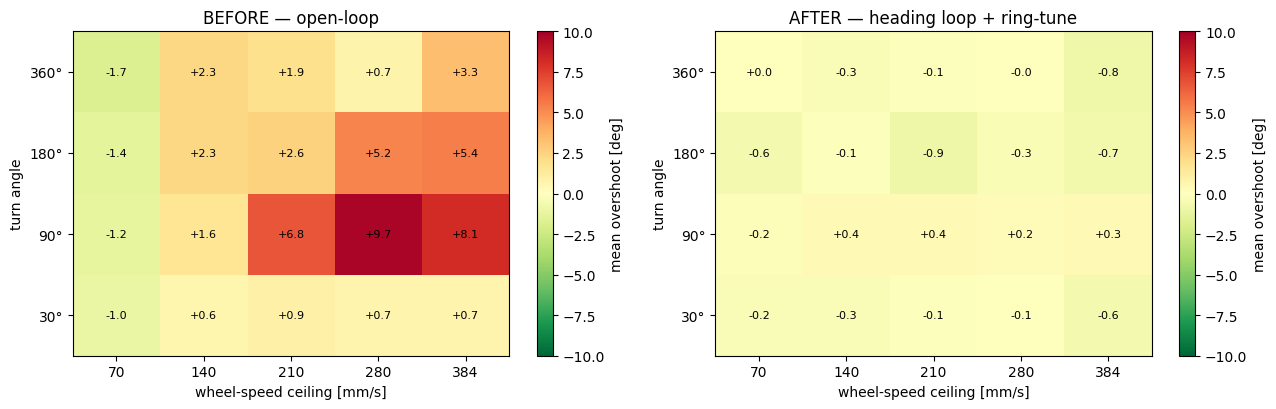

In [2]:
def cell_grid(d):
    return d.groupby(["mag","ceiling_wheel"]).overshoot_deg.mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
vmax = 10
for ax, (title, d) in zip(axes, [("BEFORE — open-loop", openloop), ("AFTER — heading loop + ring-tune", final)]):
    g = cell_grid(d)
    im = ax.imshow(g.values, aspect="auto", cmap="RdYlGn_r", vmin=-vmax, vmax=vmax, origin="lower")
    ax.set_xticks(range(len(g.columns))); ax.set_xticklabels([f"{c:.0f}" for c in g.columns])
    ax.set_yticks(range(len(g.index)));   ax.set_yticklabels([f"{i:.0f}°" for i in g.index])
    ax.set_xlabel("wheel-speed ceiling [mm/s]"); ax.set_ylabel("turn angle")
    ax.set_title(title)
    for iy in range(len(g.index)):
        for ix in range(len(g.columns)):
            v = g.values[iy, ix]
            if not np.isnan(v): ax.text(ix, iy, f"{v:+.1f}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, label="mean overshoot [deg]")
plt.tight_layout()

## 2. Overshoot vs speed — the ridge is gone

Same data as lines. Before, 90° and 180° climb steeply with speed (the ridge).
After, every angle sits on the zero line.

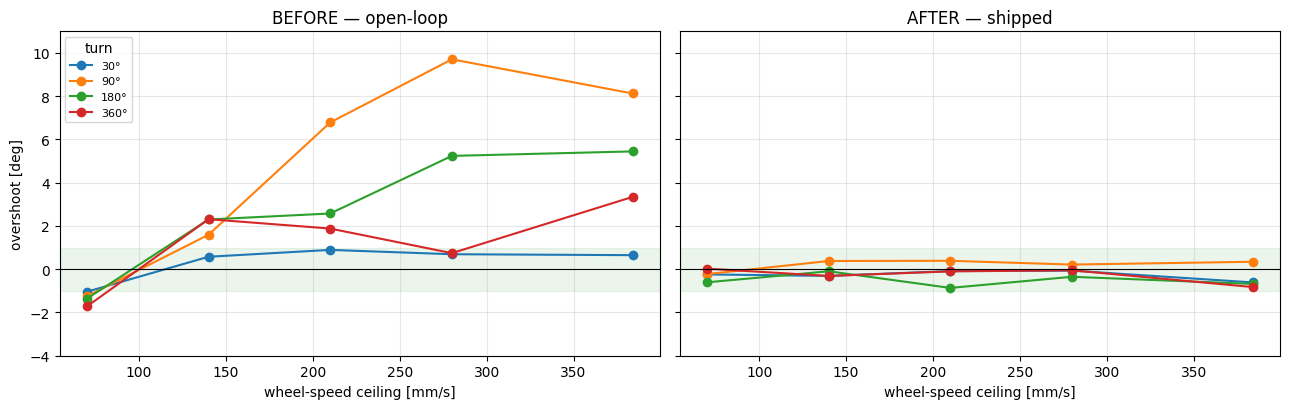

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for ax, (title, d) in zip(axes, [("BEFORE — open-loop", openloop), ("AFTER — shipped", final)]):
    for mag, sub in d.groupby("mag"):
        m = sub.groupby("ceiling_wheel").overshoot_deg.mean()
        ax.plot(m.index, m.values, "-o", label=f"{mag:.0f}°")
    ax.axhspan(-1, 1, color="green", alpha=0.08)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xlabel("wheel-speed ceiling [mm/s]"); ax.set_title(title); ax.grid(alpha=0.3)
axes[0].set_ylabel("overshoot [deg]"); axes[0].legend(title="turn", fontsize=8)
axes[0].set_ylim(-4, 11)
plt.tight_layout()

## 3. Error distribution — before vs after

Every individual turn's absolute error. The green band is the ±1° goal.

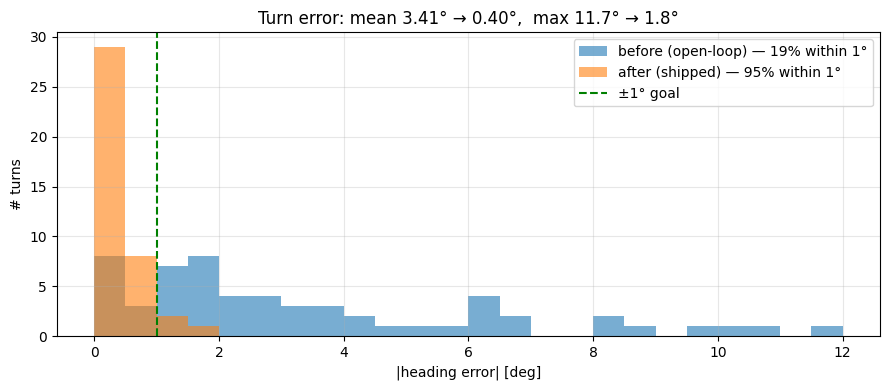

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(openloop.overshoot_deg.abs(), bins=np.arange(0, 12.5, 0.5), alpha=0.6, label=f"before (open-loop) — {stats(openloop)['within1']:.0f}% within 1°")
ax.hist(final.overshoot_deg.abs(),    bins=np.arange(0, 12.5, 0.5), alpha=0.6, label=f"after (shipped) — {stats(final)['within1']:.0f}% within 1°")
ax.axvline(1.0, color="green", ls="--", label="±1° goal")
ax.set_xlabel("|heading error| [deg]"); ax.set_ylabel("# turns"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title(f"Turn error: mean {stats(openloop)['mean']:.2f}° → {stats(final)['mean']:.2f}°,  "
             f"max {stats(openloop)['mx']:.1f}° → {stats(final)['mx']:.1f}°")
plt.tight_layout()

## 4. Inside a full-speed turn — commanded vs measured yaw rate

Full-ceiling 90/180/360° turns with the heading loop. Blue = plant behind the
plan (acceleration), red = plant ahead (deceleration). The endpoint is the small
difference of two large transients — which is exactly why an open-loop table
couldn't fix it, but a feedback loop can.

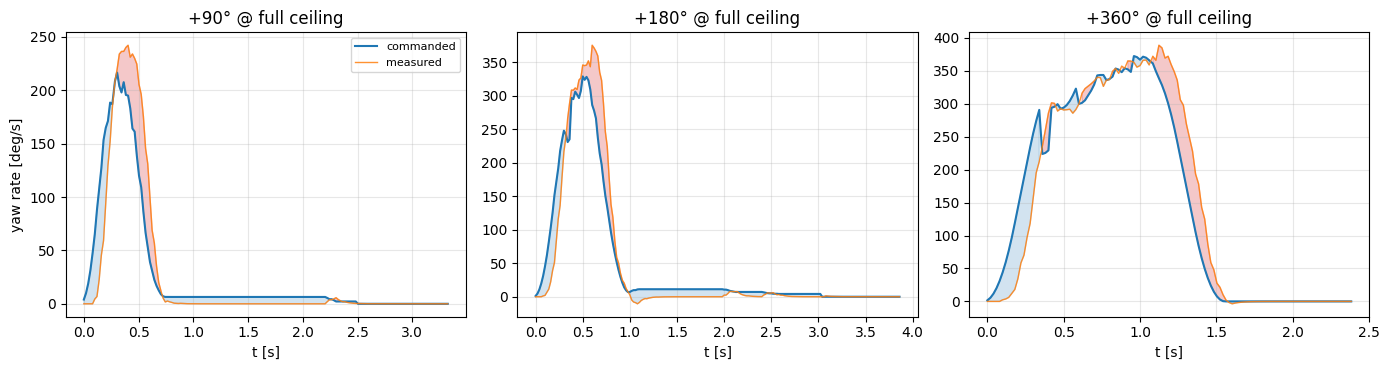

In [5]:
import glob
def yawrate(df):
    t = (df.now - df.now.iloc[0]).to_numpy()/1000.0
    cmd = np.degrees((df.cmd_vel_right - df.cmd_vel_left).to_numpy()/TW)
    meas = np.degrees((df.vel_right - df.vel_left).to_numpy()/TW)
    s = np.sign(cmd[np.argmax(np.abs(cmd))])
    return t, cmd*s, meas*s

order = ["+90_384","+180_384","+360_384"]
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, name in zip(axes, order):
    p = OUT/f"turn_trace_{name}.csv"
    if not p.exists(): continue
    t, cmd, meas = yawrate(pd.read_csv(p))
    ax.plot(t, cmd, label="commanded", lw=1.5)
    ax.plot(t, meas, label="measured", lw=1.0, alpha=0.85)
    ax.fill_between(t, cmd, meas, where=meas>cmd, color="tab:red", alpha=0.25)
    ax.fill_between(t, cmd, meas, where=meas<cmd, color="tab:blue", alpha=0.20)
    ax.set_title(f"{name.split('_')[0]}° @ full ceiling"); ax.set_xlabel("t [s]"); ax.grid(alpha=0.3)
axes[0].set_ylabel("yaw rate [deg/s]"); axes[0].legend(fontsize=8)
plt.tight_layout()

## 5. The trajectory ring — before vs after tuning

The endpoints landed, but the wheel speed **rang** during the turn (measured
overshooting the command). Diagnosed on the stand as a velocity-loop overshoot
resonance at ~140 mm/s that the heading loop over-drives the wheels into.
Tuning `vel_kp 0.0018→0.0014` (+ ki/kaw) tamed it.

A 180°@140 turn, wheel speed vs time — **left = before (vel_kp 0.0018), right =
after (0.0014).** Dashed = commanded, solid = measured.

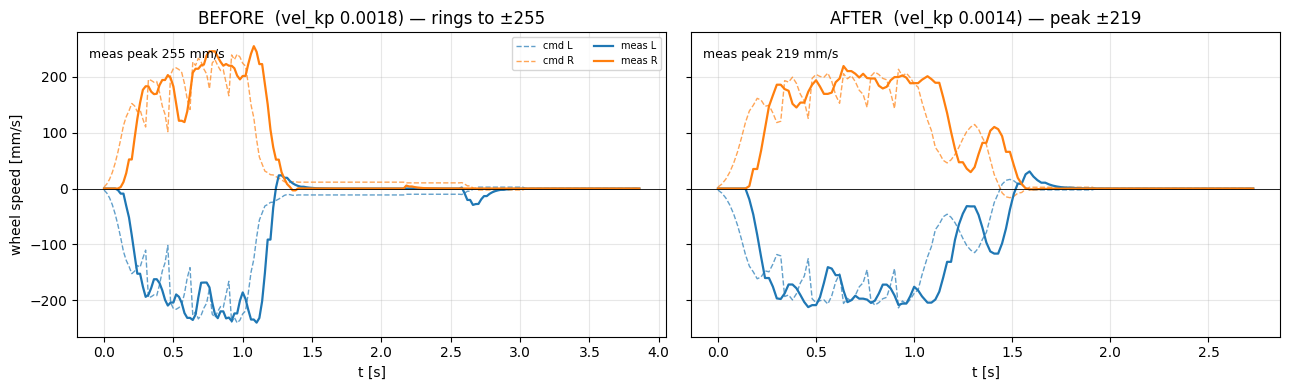

In [6]:
def plot_wheels(ax, df, title):
    t = (df.now - df.now.iloc[0]).to_numpy()/1000.0
    ax.plot(t, df.cmd_vel_left,  "--", color="tab:blue",   lw=1, alpha=0.7, label="cmd L")
    ax.plot(t, df.cmd_vel_right, "--", color="tab:orange", lw=1, alpha=0.7, label="cmd R")
    ax.plot(t, df.vel_left,  "-", color="tab:blue",   lw=1.6, label="meas L")
    ax.plot(t, df.vel_right, "-", color="tab:orange", lw=1.6, label="meas R")
    ax.axhline(0, color="k", lw=0.6); ax.set_title(title); ax.set_xlabel("t [s]"); ax.grid(alpha=0.3)
    mx = max(np.abs(df.vel_left).max(), np.abs(df.vel_right).max())
    ax.text(0.02, 0.95, f"meas peak {mx:.0f} mm/s", transform=ax.transAxes, va="top", fontsize=9)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
plot_wheels(axes[0], pd.read_csv(OUT/"ringcompare_before_pristine.csv"), "BEFORE  (vel_kp 0.0018) — rings to ±255")
plot_wheels(axes[1], pd.read_csv(OUT/"ringcompare_after_tuned.csv"),     "AFTER  (vel_kp 0.0014) — peak ±219")
axes[0].set_ylabel("wheel speed [mm/s]"); axes[0].legend(fontsize=7, ncol=2)
plt.tight_layout()

## 6. The velocity-loop resonance (why the ring, and the trade)

On-stand velocity **step** response (drive arm, planner out) — overshoot vs
commanded speed. The loop overshoots worst at ~140 mm/s, and the heading loop
drives the wheels straight into that band. Numbers measured live on the stand:

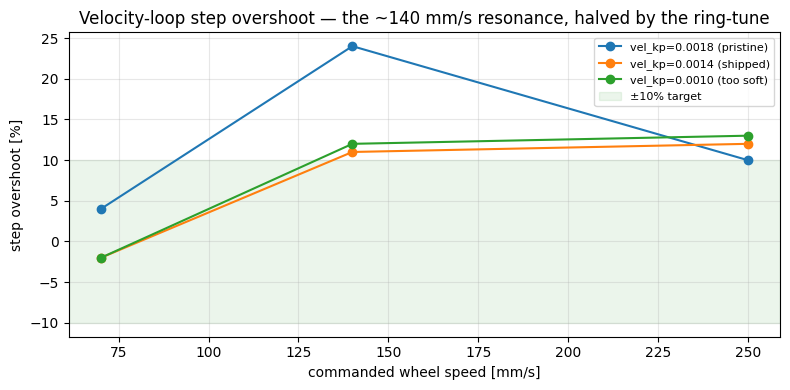

In [7]:
# measured on the stand (velocity-step overshoot %), see chat log 2026-07-12
step = pd.DataFrame({
    "speed_mmps":[70,140,250],
    "vel_kp=0.0018 (pristine)":[4,24,10],
    "vel_kp=0.0014 (shipped)":[-2,11,12],
    "vel_kp=0.0010 (too soft)":[-2,12,13],
})
fig, ax = plt.subplots(figsize=(8,4))
for col in step.columns[1:]:
    ax.plot(step.speed_mmps, step[col], "-o", label=col)
ax.axhspan(-10,10, color="green", alpha=0.08, label="±10% target")
ax.set_xlabel("commanded wheel speed [mm/s]"); ax.set_ylabel("step overshoot [%]")
ax.set_title("Velocity-loop step overshoot — the ~140 mm/s resonance, halved by the ring-tune")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()

## Summary

| | before (open-loop) | after (shipped) |
|---|---|---|
| mean \|error\| | see cell 1 | see cell 1 |
| within ±1° | ~19% | ~95% |
| 90° full-speed ridge | +8–10° | gone |
| trajectory ring (step overshoot @140) | +24% | +11% |

**Shipped:** heading-loop cascade (`heading_kp=6`, live-tunable over radio) +
ring-tuned velocity gains (`vel_kp 0.0018→0.0014`). Endpoint holds ~95% within
±1° with a much smoother trajectory. The remaining "have-it-both-ways" fix (clamp
the heading-loop output to the ceiling, keep the stiff inner loop) is filed at
`clasi/issues/heading-loop-output-clamp-and-velocity-resonance.md`.